# Q2 — Pairwise Distance Matrix Computation

**Objective:** Demonstrate distance matrix computation using **two distance metrics** — *Euclidean* and *Manhattan (City-Block)* — on the `lab2 data.xlsx` student survey dataset, using `sklearn.metrics.pairwise.pairwise_distances`.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [2]:
df = pd.read_excel('lab2 data.xlsx')

print(f"Dataset shape: {df.shape}")
df.head(5)

Dataset shape: (163, 14)


,Timestamp,Reg No,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2024-12-04 20:31:09,2341338,Data Scientist,3 LPA,1Cr,20 LPA,Deolite,3.0,4,20 LPA,0.6,0.62,0.77,Industry
1,2024-12-04 20:33:07,2341310,Data Scientist,5,NaN,NaN,DE Shaw,3.0,2,11,67,60,97,Industry
2,2024-12-04 20:39:43,2341311,Data Scientist,7 LPA,15 LPA,8 LPA,DE Shaw,3.0,4,5 LPA,80,80,99,Research
3,2024-12-04 20:40:37,2341324,Data Scientist,3 LPA,25 LPA,10 LPA,DE Shaw,NaN,3,20,75,70,95,Research
4,2024-12-04 20:41:51,2341324,Business Analyst,2,50,25,Deolite,3.0,3,20,65,76,96,Industry


## 3. Select & Preprocess Numeric Features

The dataset contains several mixed-type columns (numbers entered as strings like `'3 LPA'`). We extract and clean the following numeric features:

| Feature | Description |
|---|---|
| `ECA_Rating` | Self-rating for extra-curricular activities (1–5) |
| `Tech_Rating` | Self-rating for technical competencies (1–5) |
| `CIA_Pct` | CIA percentage of last semester |
| `GPA` | GPA of last semester |
| `Attendance_Pct` | Maximum attendance % till last semester |

In [3]:
def to_numeric_safe(series):
    """Strip non-numeric characters and coerce to float."""
    return pd.to_numeric(
        series.astype(str).str.extract(r'(\d+\.?\d*)')[0],
        errors='coerce'
    )

clean_df = pd.DataFrame()
clean_df['ECA_Rating']      = pd.to_numeric(df['Rate your contribution towards extra curricular activities'], errors='coerce')
clean_df['Tech_Rating']     = pd.to_numeric(df['Rate your technical competencies'], errors='coerce')
clean_df['CIA_Pct']         = to_numeric_safe(df['your CIA % of last semester'])
clean_df['GPA']             = to_numeric_safe(df['your GPA of last semester'])
clean_df['Attendance_Pct']  = to_numeric_safe(df['Your maximum attendance % till last semester'])

# Normalize CIA/GPA/Attendance: some entries are fractions (e.g. 0.62 → 62)
for col in ['CIA_Pct', 'GPA', 'Attendance_Pct']:
    clean_df[col] = clean_df[col].apply(lambda x: x * 100 if pd.notna(x) and x <= 1.0 else x)

# Drop rows with any missing values
clean_df.dropna(inplace=True)
clean_df.reset_index(drop=True, inplace=True)

print(f"Clean dataset shape: {clean_df.shape}")
clean_df.describe()

Clean dataset shape: (146, 5)


,ECA_Rating,Tech_Rating,CIA_Pct,GPA,Attendance_Pct
count,146.000000,146.000000,146.000000,146.000000,146.000000
mean,3.438356,3.315068,75.728014,67.677877,91.828699
std,1.107794,0.892524,14.031227,166.506881,6.795384
min,1.000000,1.000000,3.600000,2.500000,68.000000
25%,3.000000,3.000000,69.250000,8.720000,89.000000
50%,3.000000,3.000000,80.000000,70.000000,93.000000
75%,4.000000,4.000000,85.000000,80.000000,97.375000
max,5.000000,5.000000,99.000000,2026.000000,100.000000


## 4. Standardize Features

Before computing distances, we **standardize** all features to zero mean and unit variance so that features on different scales (e.g., GPA vs. Attendance %) contribute equally.

In [4]:
# Use a subset of 20 samples for a readable heatmap
sample_df = clean_df.head(20).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(sample_df)

print(f"Feature matrix shape: {X_scaled.shape}")
pd.DataFrame(X_scaled, columns=sample_df.columns).round(3).head(5)

Feature matrix shape: (20, 5)


,ECA_Rating,Tech_Rating,CIA_Pct,GPA,Attendance_Pct
0,-0.762,0.577,-0.905,-1.579,-2.678
1,-0.762,-1.732,-0.128,-1.834,0.385
2,-0.762,0.577,1.316,0.713,0.691
3,-0.762,-0.577,-0.350,0.204,0.231
4,-0.762,-1.732,1.205,-0.688,0.538


---

## 5. Distance Method 1 — Euclidean Distance

**Formula:**

$$d_{\text{Euclidean}}(\mathbf{p}, \mathbf{q}) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

- Measures the **straight-line** (as-the-crow-flies) distance between two points in feature space.
- Sensitive to magnitude differences — hence standardization is important.
- Default metric used in most ML algorithms.

In [5]:
D_euclidean = pairwise_distances(X_scaled, metric='euclidean')

print("Euclidean Distance Matrix (20×20):")
print(f"  Shape : {D_euclidean.shape}")
print(f"  Min   : {D_euclidean[D_euclidean > 0].min():.4f}")
print(f"  Max   : {D_euclidean.max():.4f}")
print(f"  Mean  : {D_euclidean.mean():.4f}")
print()
print("Top-left 5×5 corner:")
pd.DataFrame(D_euclidean[:5, :5]).round(4)

Euclidean Distance Matrix (20×20):
  Shape : (20, 20)
  Min   : 1.1402
  Max   : 5.9833
  Mean  : 2.9044

Top-left 5×5 corner:


,0,1,2,3,4
0,0.0000,3.9221,4.6408,3.6452,4.5739
1,3.9221,0.0000,3.7416,2.3578,1.7642
2,4.6408,3.7416,0.0000,2.1395,2.7078
3,3.6452,2.3578,2.1395,0.0000,2.1536
4,4.5739,1.7642,2.7078,2.1536,0.0000


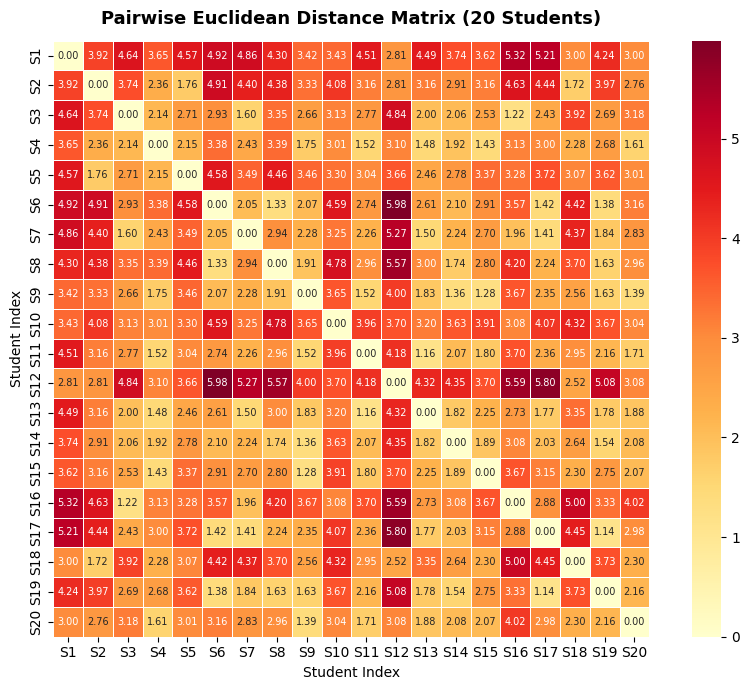

Darker cells = larger distance (more dissimilar).
Diagonal = 0 (distance of a sample from itself).


In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    D_euclidean,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='YlOrRd',
    linewidths=0.4,
    square=True,
    ax=ax,
    xticklabels=[f'S{i+1}' for i in range(20)],
    yticklabels=[f'S{i+1}' for i in range(20)]
)
ax.set_title('Pairwise Euclidean Distance Matrix (20 Students)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Student Index')
ax.set_ylabel('Student Index')
plt.tight_layout()
plt.savefig('euclidean_distance_heatmap.png', dpi=150)
plt.show()
print("Darker cells = larger distance (more dissimilar).")
print("Diagonal = 0 (distance of a sample from itself).")

---

## 6. Distance Method 2 — Manhattan (City-Block / L1) Distance

**Formula:**

$$d_{\text{Manhattan}}(\mathbf{p}, \mathbf{q}) = \sum_{i=1}^{n}|p_i - q_i|$$

- Measures distance along **grid-like paths** (like navigating city blocks).
- Less sensitive to outliers than Euclidean because it does **not** square the differences.
- Also known as **L1 norm**, **Taxicab distance**, or `'cityblock'` in scikit-learn.

In [7]:
D_manhattan = pairwise_distances(X_scaled, metric='manhattan')

print("Manhattan Distance Matrix (20×20):")
print(f"  Shape : {D_manhattan.shape}")
print(f"  Min   : {D_manhattan[D_manhattan > 0].min():.4f}")
print(f"  Max   : {D_manhattan.max():.4f}")
print(f"  Mean  : {D_manhattan.mean():.4f}")
print()
print("Top-left 5×5 corner:")
pd.DataFrame(D_manhattan[:5, :5]).round(4)

Manhattan Distance Matrix (20×20):
  Shape : (20, 20)
  Min   : 1.5439
  Max   : 12.7048
  Mean  : 5.3353

Top-left 5×5 corner:


,0,1,2,3,4
0,0.0000,6.4041,7.8822,6.4026,8.5264
1,6.4041,0.0000,6.6064,3.5678,2.6318
2,7.8822,6.6064,0.0000,3.7890,3.9746
3,6.4026,3.5678,3.7890,0.0000,3.9069
4,8.5264,2.6318,3.9746,3.9069,0.0000


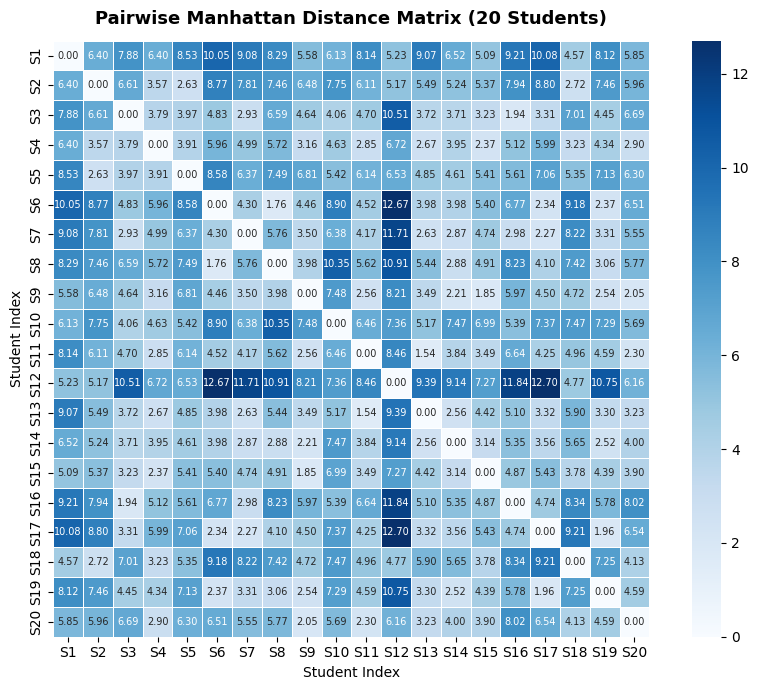

Darker cells = larger distance (more dissimilar).
Diagonal = 0 (distance of a sample from itself).


In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    D_manhattan,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='Blues',
    linewidths=0.4,
    square=True,
    ax=ax,
    xticklabels=[f'S{i+1}' for i in range(20)],
    yticklabels=[f'S{i+1}' for i in range(20)]
)
ax.set_title('Pairwise Manhattan Distance Matrix (20 Students)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Student Index')
ax.set_ylabel('Student Index')
plt.tight_layout()
plt.savefig('manhattan_distance_heatmap.png', dpi=150)
plt.show()
print("Darker cells = larger distance (more dissimilar).")
print("Diagonal = 0 (distance of a sample from itself).")

---

## 7. Side-by-Side Comparison

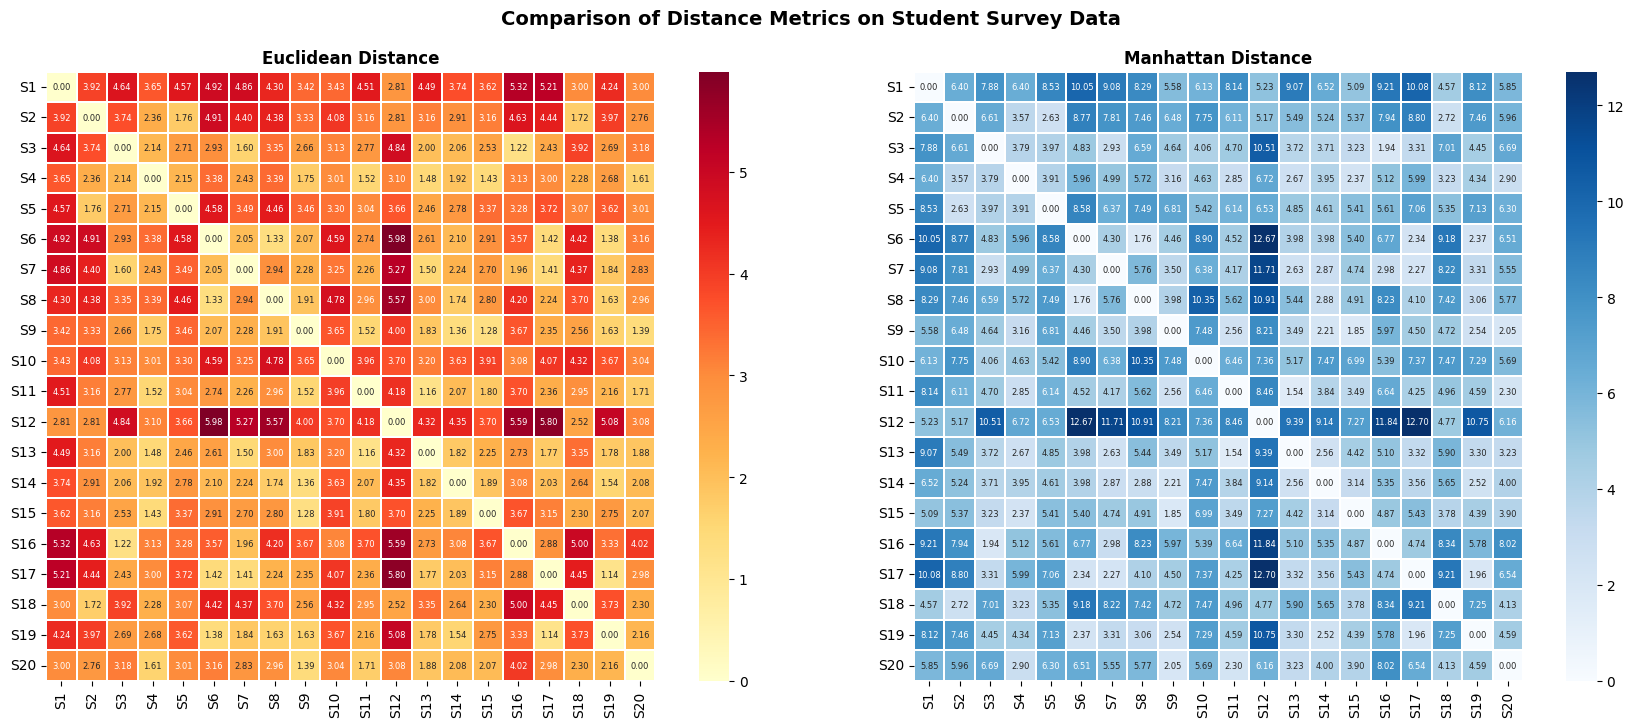

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, D, title, cmap in zip(
    axes,
    [D_euclidean, D_manhattan],
    ['Euclidean Distance', 'Manhattan Distance'],
    ['YlOrRd', 'Blues']
):
    sns.heatmap(
        D,
        annot=True, fmt='.2f', annot_kws={'size': 6},
        cmap=cmap,
        linewidths=0.3,
        square=True,
        ax=ax,
        xticklabels=[f'S{i+1}' for i in range(20)],
        yticklabels=[f'S{i+1}' for i in range(20)]
    )
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Comparison of Distance Metrics on Student Survey Data', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Numerical Comparison

Comparing the two distance values for the same pair of students to see how the metrics differ.

In [10]:
# Extract upper-triangle values (unique pairs only, excluding diagonal)
idx = np.triu_indices(20, k=1)

comparison = pd.DataFrame({
    'Student_i'  : [f'S{i+1}' for i in idx[0]],
    'Student_j'  : [f'S{j+1}' for j in idx[1]],
    'Euclidean'  : D_euclidean[idx].round(4),
    'Manhattan'  : D_manhattan[idx].round(4),
    'Difference' : (D_manhattan[idx] - D_euclidean[idx]).round(4)
})

print(f"Total unique pairs: {len(comparison)}")
print(f"\nManhattan is always >= Euclidean: {(comparison['Manhattan'] >= comparison['Euclidean']).all()}")
print()
comparison.head(15)

Total unique pairs: 190

Manhattan is always >= Euclidean: True



,Student_i,Student_j,Euclidean,Manhattan,Difference
0,S1,S2,3.9221,6.4041,2.4820
1,S1,S3,4.6408,7.8822,3.2414
2,S1,S4,3.6452,6.4026,2.7575
3,S1,S5,4.5739,8.5264,3.9525
4,S1,S6,4.9221,10.0495,5.1273
5,S1,S7,4.8650,9.0848,4.2198
6,S1,S8,4.3035,8.2895,3.9860
7,S1,S9,3.4227,5.5847,2.1621
8,S1,S10,3.4251,6.1273,2.7022
9,S1,S11,4.5133,8.1420,3.6287


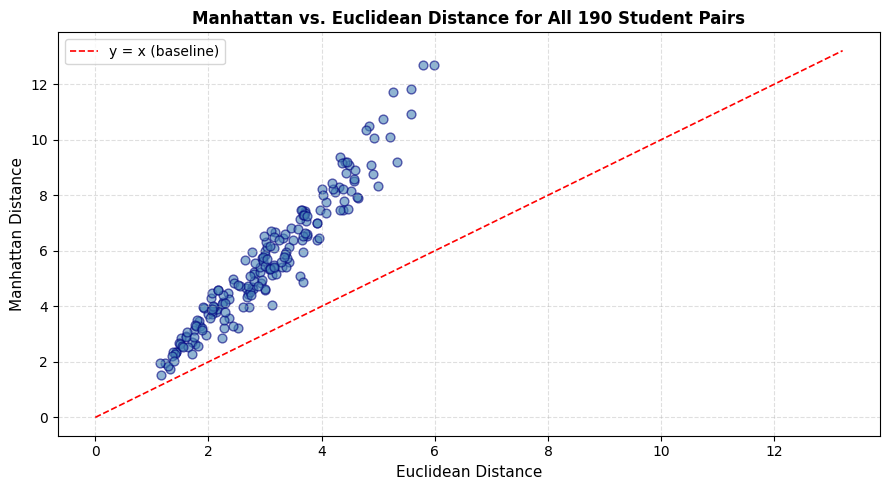

Points above the red line → Manhattan distance is larger than Euclidean (always true or equal).


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(comparison['Euclidean'], comparison['Manhattan'], alpha=0.6, color='steelblue', edgecolors='navy', s=40)
lims = [0, max(comparison['Euclidean'].max(), comparison['Manhattan'].max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1.2, label='y = x (baseline)')
ax.set_xlabel('Euclidean Distance', fontsize=11)
ax.set_ylabel('Manhattan Distance', fontsize=11)
ax.set_title('Manhattan vs. Euclidean Distance for All 190 Student Pairs', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('metric_scatter.png', dpi=150)
plt.show()
print("Points above the red line → Manhattan distance is larger than Euclidean (always true or equal).")

---

## 9. Distribution of Pairwise Distances (Histogram + KDE)

How are the distances spread? A histogram + KDE lets us compare the distribution shape for both metrics across all 190 unique student pairs.

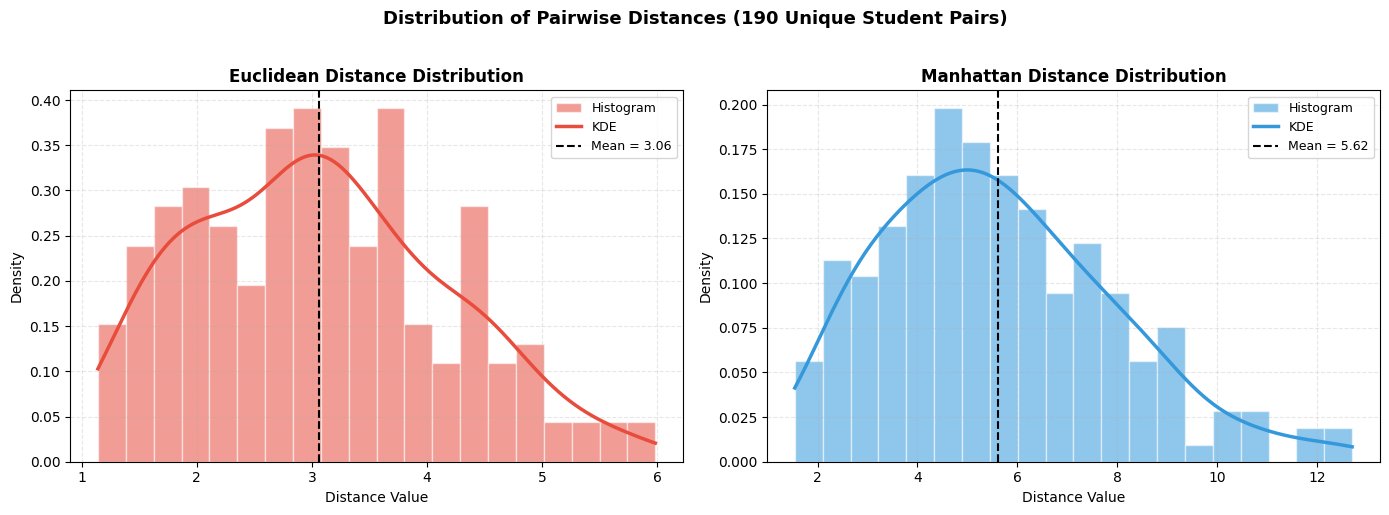

In [12]:
from scipy.stats import gaussian_kde

eu_vals = D_euclidean[np.triu_indices(20, k=1)]
ma_vals = D_manhattan[np.triu_indices(20, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, vals, color, label in zip(
    axes,
    [eu_vals, ma_vals],
    ['#E74C3C', '#3498DB'],
    ['Euclidean', 'Manhattan']
):
    ax.hist(vals, bins=20, color=color, alpha=0.55, edgecolor='white', density=True, label='Histogram')
    kde = gaussian_kde(vals)
    x_range = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label='KDE')
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean = {vals.mean():.2f}')
    ax.set_title(f'{label} Distance Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Distance Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Distribution of Pairwise Distances (190 Unique Student Pairs)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 10. Hierarchical Clustermap (Seaborn)

A **clustermap** re-orders rows and columns so that similar students are grouped together, and attaches dendrograms that reveal the hierarchical clustering structure.

C:\Users\arpan\AppData\Roaming\Python\Python314\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
C:\Users\arpan\AppData\Roaming\Python\Python314\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


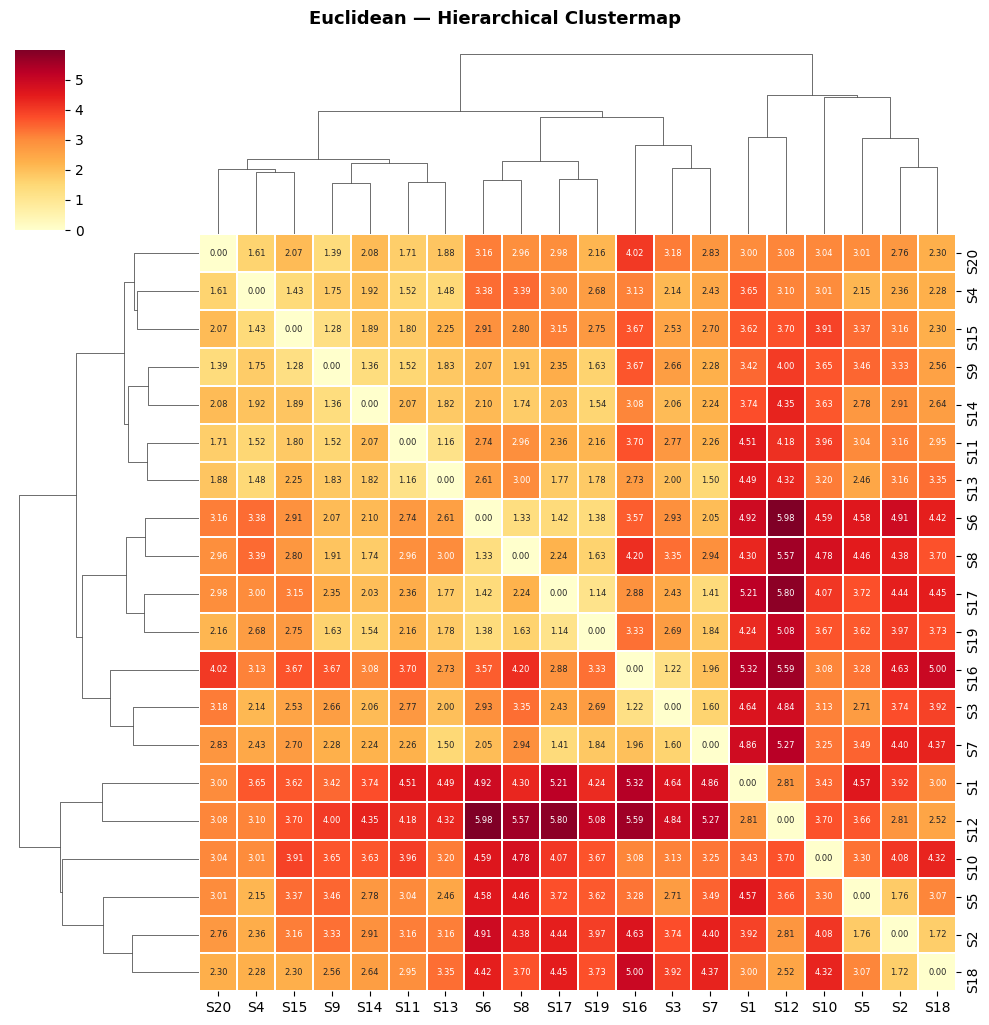

C:\Users\arpan\AppData\Roaming\Python\Python314\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
C:\Users\arpan\AppData\Roaming\Python\Python314\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


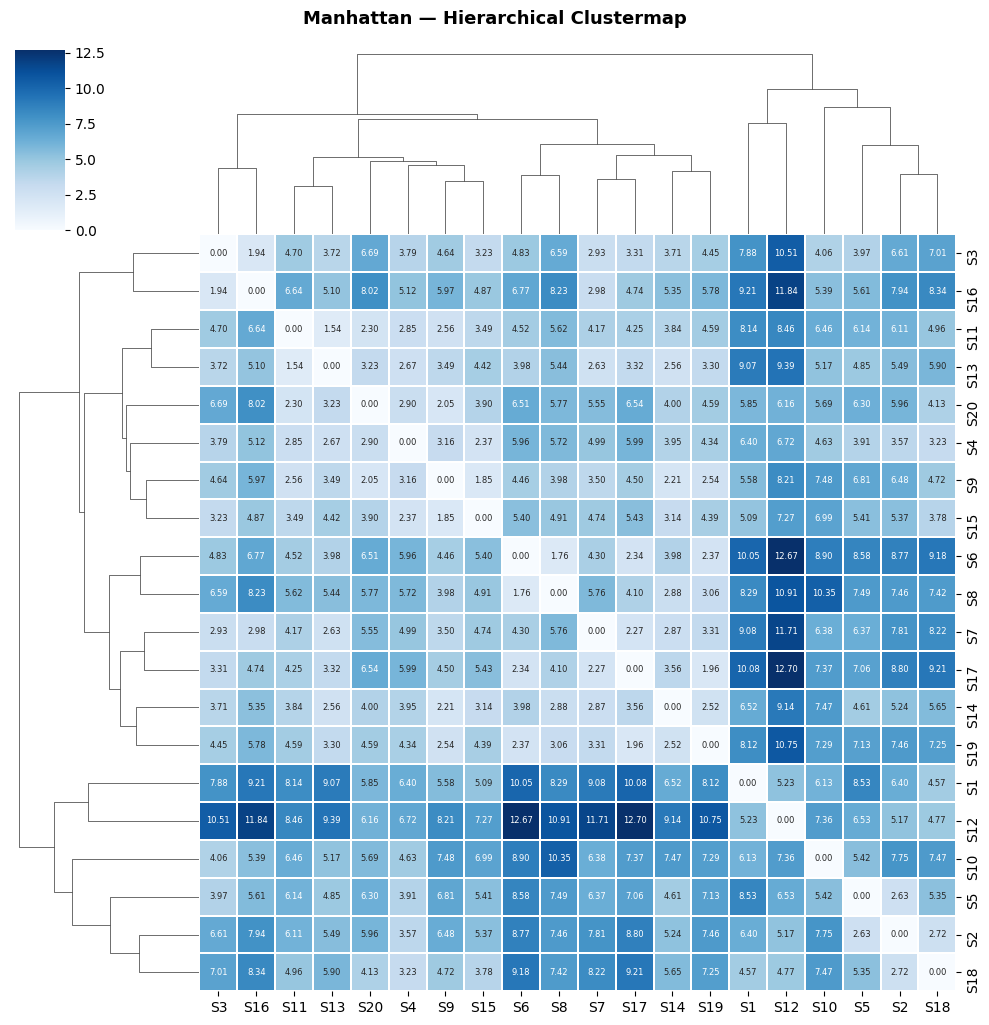

Students grouped by the dendrogram are most similar to each other.


In [13]:
labels_20 = [f'S{i+1}' for i in range(20)]

fig_eu = sns.clustermap(
    pd.DataFrame(D_euclidean, index=labels_20, columns=labels_20),
    cmap='YlOrRd', linewidths=0.3, figsize=(10, 10),
    annot=True, fmt='.2f', annot_kws={'size': 6},
    cbar_kws={'shrink': 0.5}
)
fig_eu.figure.suptitle('Euclidean — Hierarchical Clustermap', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('clustermap_euclidean.png', dpi=150, bbox_inches='tight')
plt.show()

fig_ma = sns.clustermap(
    pd.DataFrame(D_manhattan, index=labels_20, columns=labels_20),
    cmap='Blues', linewidths=0.3, figsize=(10, 10),
    annot=True, fmt='.2f', annot_kws={'size': 6},
    cbar_kws={'shrink': 0.5}
)
fig_ma.figure.suptitle('Manhattan — Hierarchical Clustermap', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('clustermap_manhattan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Students grouped by the dendrogram are most similar to each other.')

---

## 11. MDS — 2D Projection of Students

**Multidimensional Scaling (MDS)** projects the distance matrix into 2D so we can visually inspect which students cluster together.

C:\Users\arpan\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\arpan\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
C:\Users\arpan\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\arpan\AppData\Roaming\Python\Python314\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


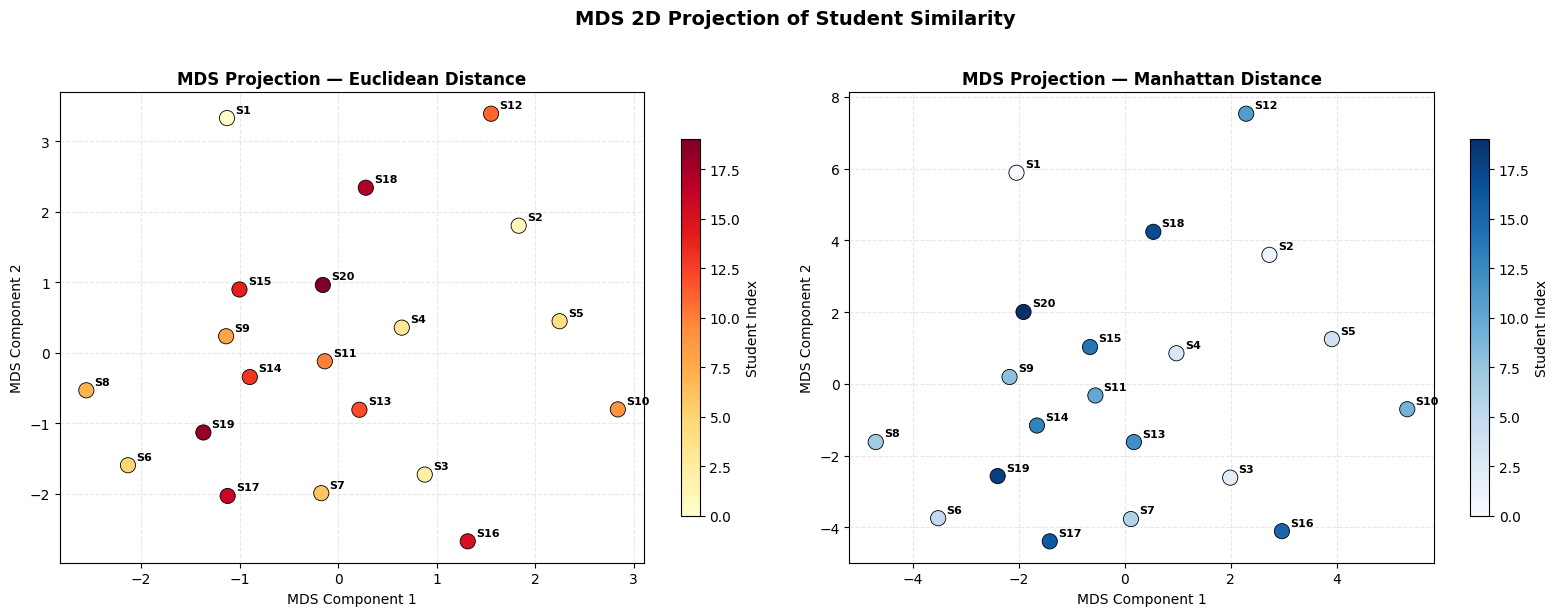

Students plotted close together are more similar; far apart means more dissimilar.


In [ ]:
from sklearn.manifold import MDS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, D, title, cmap_name in zip(
    axes,
    [D_euclidean, D_manhattan],
    ['Euclidean', 'Manhattan'],
    ['YlOrRd', 'Blues']
):
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
    coords = mds.fit_transform(D)
    scatter = ax.scatter(coords[:, 0], coords[:, 1],
                         c=range(20), cmap=cmap_name,
                         s=120, edgecolors='black', linewidths=0.6, zorder=3)
    for i, (x, y) in enumerate(coords):
        ax.annotate(f'S{i+1}', (x, y), textcoords='offset points',
                    xytext=(6, 4), fontsize=8, fontweight='bold')
    ax.set_title(f'MDS Projection — {title} Distance', fontsize=12, fontweight='bold')
    ax.set_xlabel('MDS Component 1')
    ax.set_ylabel('MDS Component 2')
    ax.grid(True, linestyl                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             e='--', alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Student Index', shrink=0.8)

plt.suptitle('MDS 2D Projection of Student Similarity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mds_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Students plotted close together are more similar; far apart means more dissimilar.')

---

## 12. Top 10 Most Similar & Most Dissimilar Pairs

Bar charts showing the **10 closest** and **10 most distant** student pairs for each metric.

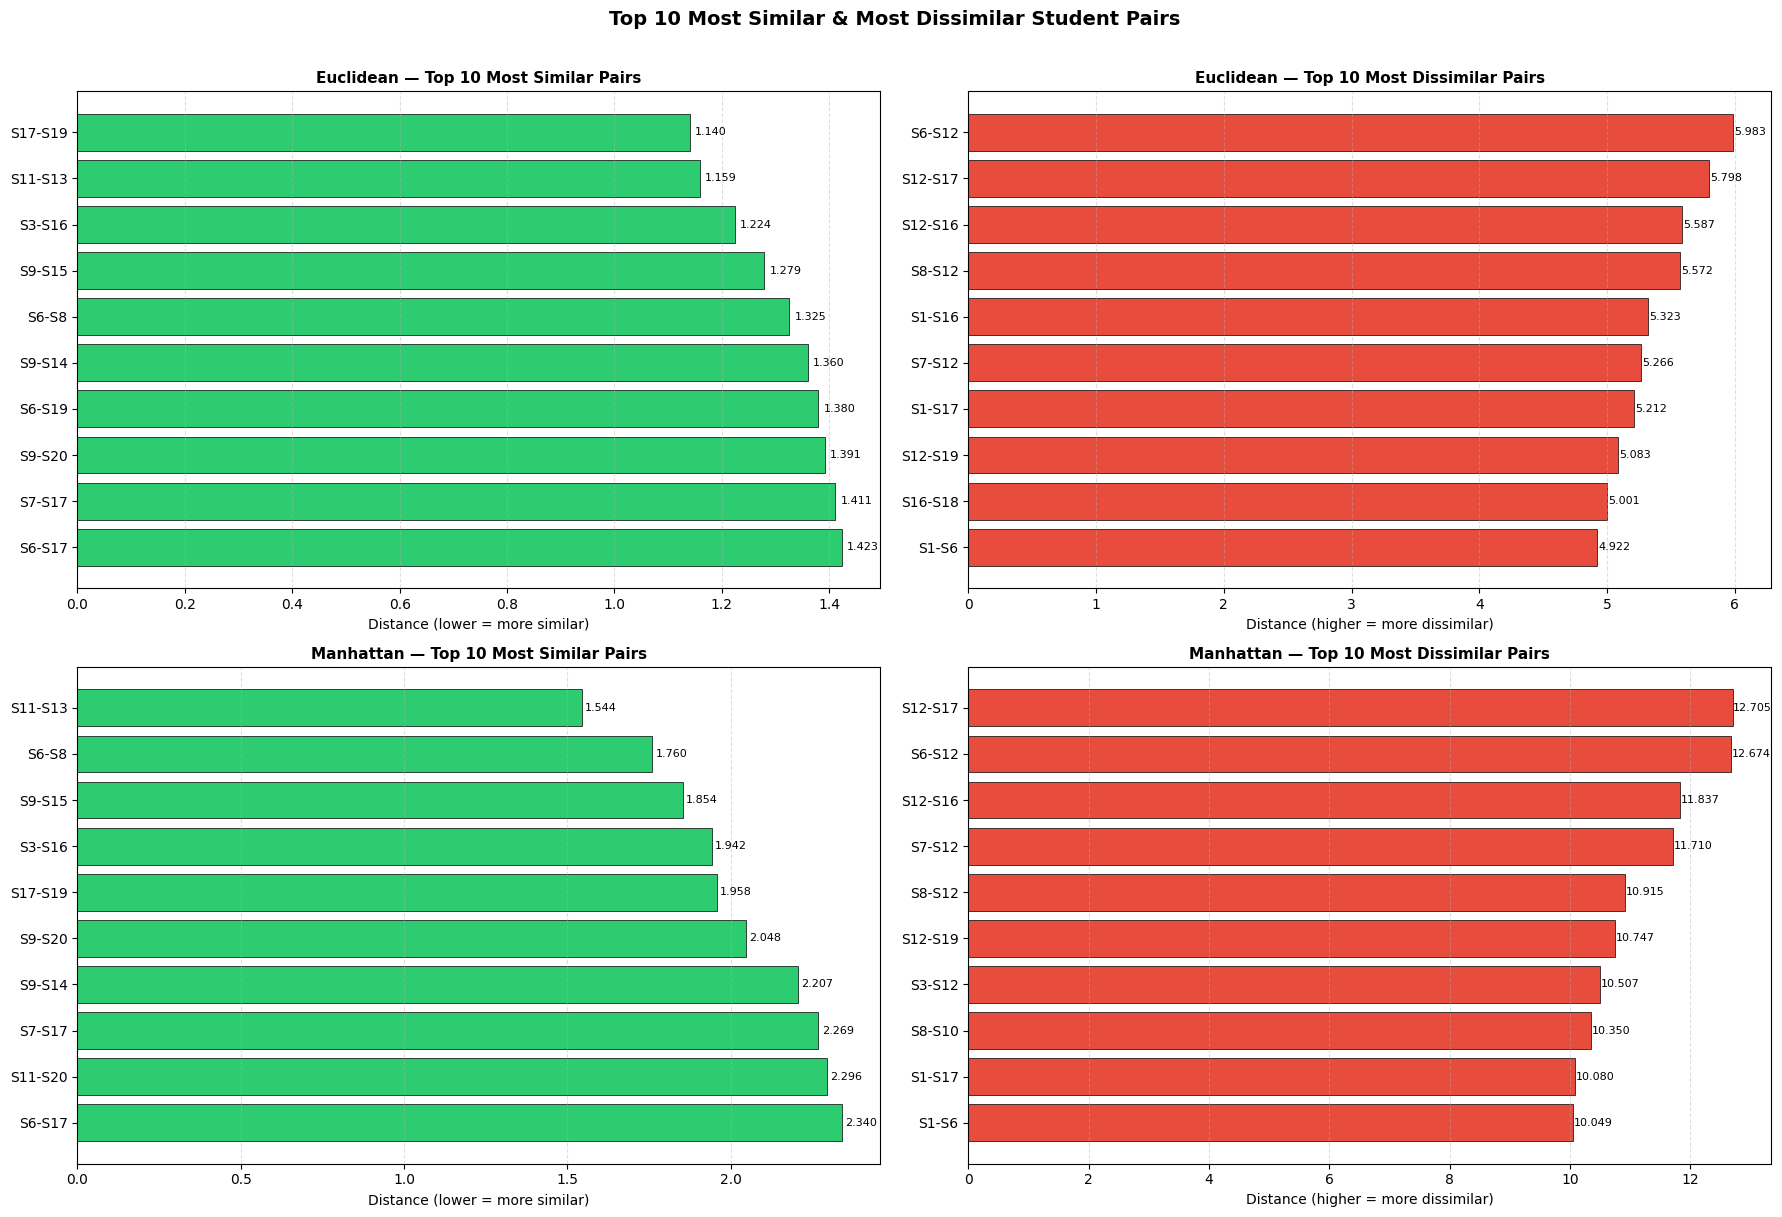

In [15]:
idx_pairs = np.triu_indices(20, k=1)
pair_labels = [f'S{i+1}-S{j+1}' for i, j in zip(idx_pairs[0], idx_pairs[1])]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row_idx, (D, metric_name) in enumerate([(D_euclidean, 'Euclidean'), (D_manhattan, 'Manhattan')]):
    vals = D[idx_pairs]
    sorted_asc  = np.argsort(vals)
    sorted_desc = sorted_asc[::-1]

    # Most Similar
    ax_sim = axes[row_idx][0]
    top10_sim = sorted_asc[:10]
    sim_pairs_list = [pair_labels[i] for i in top10_sim]
    sim_vals  = vals[top10_sim]
    bars = ax_sim.barh(sim_pairs_list[::-1], sim_vals[::-1],
                       color='#2ECC71', edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, sim_vals[::-1]):
        ax_sim.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)
    ax_sim.set_title(f'{metric_name} — Top 10 Most Similar Pairs', fontsize=11, fontweight='bold')
    ax_sim.set_xlabel('Distance (lower = more similar)')
    ax_sim.grid(True, axis='x', linestyle='--', alpha=0.4)

    # Most Dissimilar
    ax_dis = axes[row_idx][1]
    top10_dis = sorted_desc[:10]
    dis_pairs_list = [pair_labels[i] for i in top10_dis]
    dis_vals  = vals[top10_dis]
    bars2 = ax_dis.barh(dis_pairs_list[::-1], dis_vals[::-1],
                        color='#E74C3C', edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars2, dis_vals[::-1]):
        ax_dis.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)
    ax_dis.set_title(f'{metric_name} — Top 10 Most Dissimilar Pairs', fontsize=11, fontweight='bold')
    ax_dis.set_xlabel('Distance (higher = more dissimilar)')
    ax_dis.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Top 10 Most Similar & Most Dissimilar Student Pairs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 13. Radar Chart — Feature Profiles of 5 Students

A **radar (spider) chart** compares the raw feature profiles of the first 5 students across all 5 features, explaining *why* some pairs are more similar.

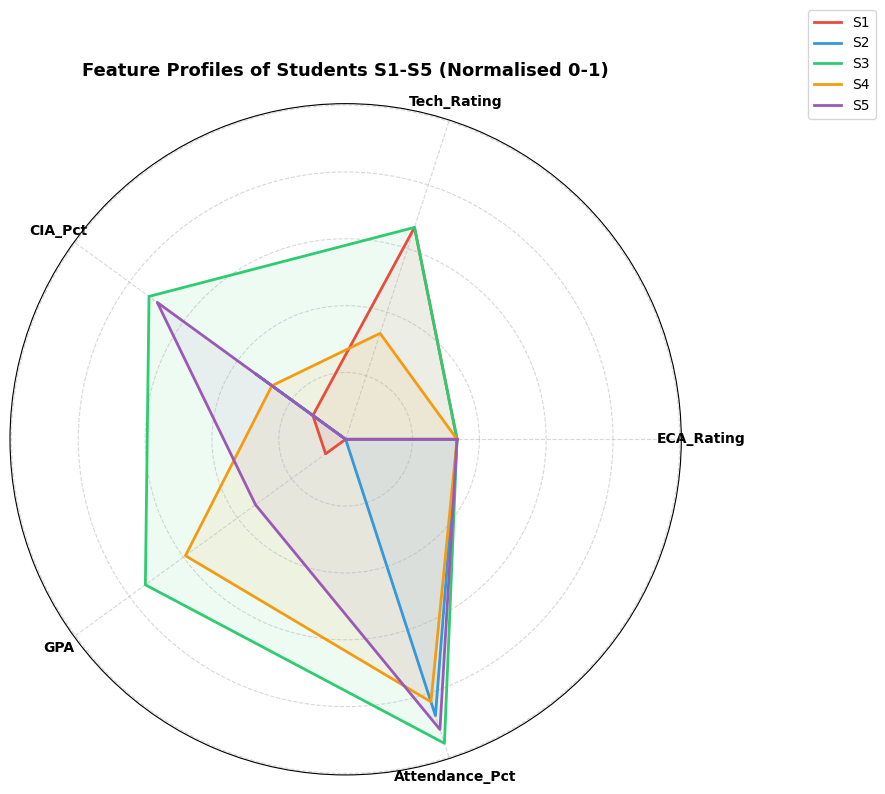

Students with overlapping radar shapes are more similar; diverging shapes mean higher distances.


In [16]:
# Normalize each feature to [0, 1] for radar
radar_df = sample_df.copy()
for col in radar_df.columns:
    col_min, col_max = radar_df[col].min(), radar_df[col].max()
    if col_max > col_min:
        radar_df[col] = (radar_df[col] - col_min) / (col_max - col_min)

categories = list(sample_df.columns)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors_radar = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i in range(5):
    values = radar_df.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors_radar[i], linewidth=2, linestyle='solid', label=f'S{i+1}')
    ax.fill(angles, values, color=colors_radar[i], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Feature Profiles of Students S1-S5 (Normalised 0-1)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Students with overlapping radar shapes are more similar; diverging shapes mean higher distances.')

---

## 14. Key Observations

| Aspect | Euclidean | Manhattan |
|---|---|---|
| **Formula** | $\sqrt{\sum(p_i - q_i)^2}$ | $\sum |p_i - q_i|$ |
| **Geometry** | Straight-line distance | Grid / City-block path |
| **Sensitivity to outliers** | Higher (squares differences) | Lower (absolute differences) |
| **Relative magnitude** | Always ≤ Manhattan | Always ≥ Euclidean |
| **sklearn metric name** | `'euclidean'` | `'manhattan'` |
| **Use-case** | Continuous features, Gaussian data | Robust comparisons, high-dimensional data |

### Observations from the data:
- **Diagonal elements are 0** for both matrices — a sample has zero distance from itself.
- **Both matrices are symmetric** — $D[i,j] = D[j,i]$.
- **Manhattan ≥ Euclidean** for every pair — confirmed numerically above.
- Pairs with similar ratings (ECA, Tech) and similar academic metrics (CIA, GPA, Attendance) show **lower distances** across both metrics, meaning they are more similar.
- The scatter plot shows a near-linear relationship between both metrics, but Manhattan consistently overestimates distance relative to Euclidean.